<a href="https://colab.research.google.com/github/amelija-indrekus/BAA1030/blob/main/BAA1030_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
title: "Addressing Global Inequalities in Water Access"
author: "Amelija Indrekus"
format:
html:
    embed-resources: true
    code-fold: true
---

In [14]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import polars as pl

In [16]:
inidicator = pl.read_csv("unicef_indicator_2.csv")
metadata = pl.read_csv("unicef_metadata.csv")

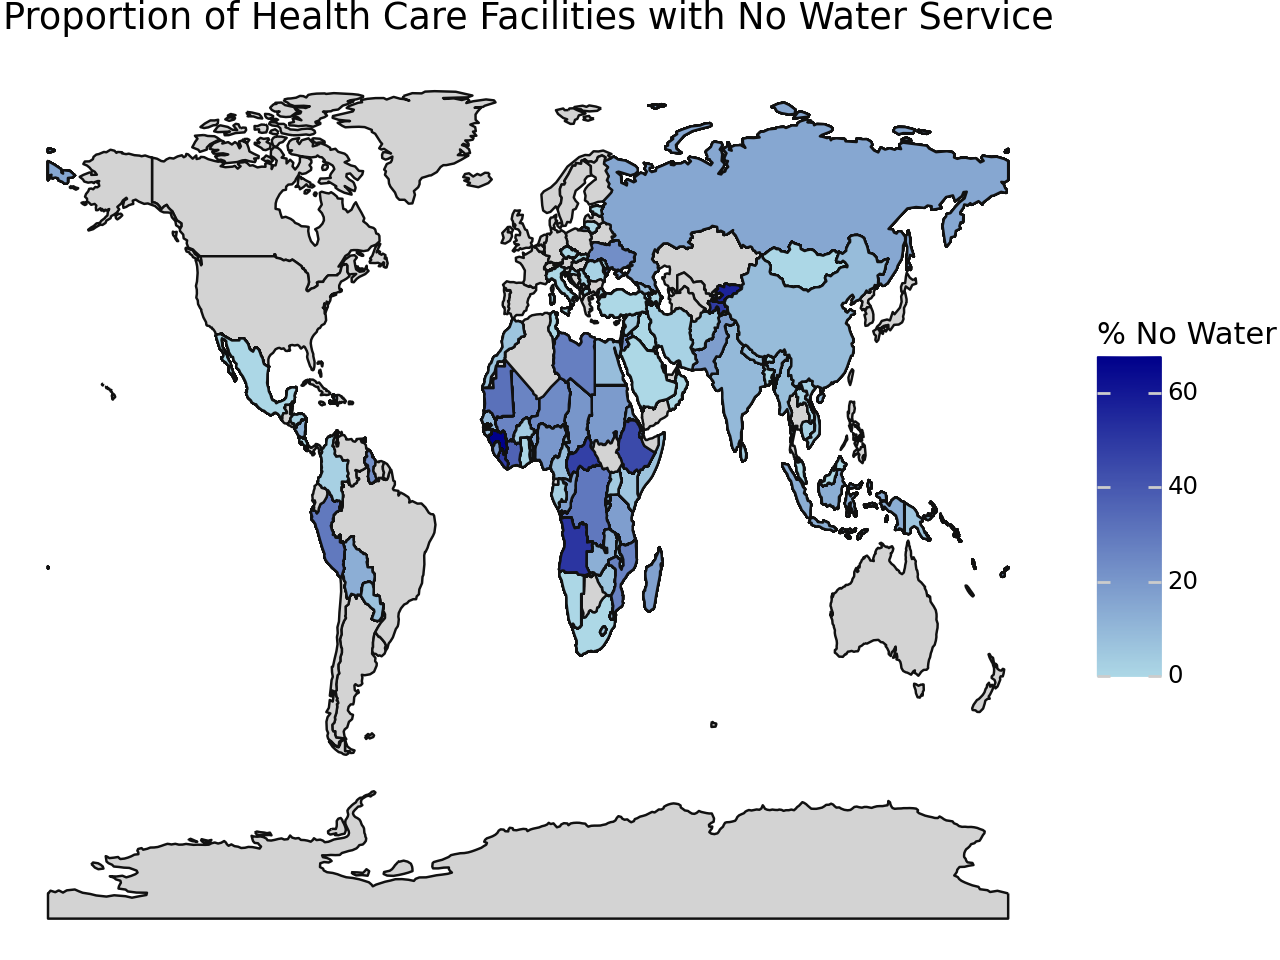

In [17]:
from plotnine import *
import geopandas as gpd
import polars as pl

indicator = pl.read_csv("unicef_indicator_2.csv")

world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

indicator_pd = indicator.to_pandas()

world_merged = world.merge(indicator_pd, left_on="ADM0_A3", right_on="alpha_3_code", how="left")

(
    ggplot(world_merged)
    + aes(fill="obs_value")
    + geom_map()
   + scale_fill_gradient(low="lightblue", high="darkblue", na_value="lightgrey")
    + labs(title="Proportion of Health Care Facilities with No Water Service", fill="% No Water")
    + theme_void()
)

According to data, **1 in 10** people worlwide are treated in health care facilities **without** clean water.

However, the proportion of health services that have access to water greatly varies among countries, wuth the most developed countries having 100% access, whilst the world's least developed countries show considerable lower figures, as showcased by the map.

*Globally, ***724 million*** people are affected by health services with no acces to water*

Thus, it is crucal to address this due to its lasting social and health impacts.



**The Central African region shows varying differences in water access between countries, providing an interesting and complex example.**

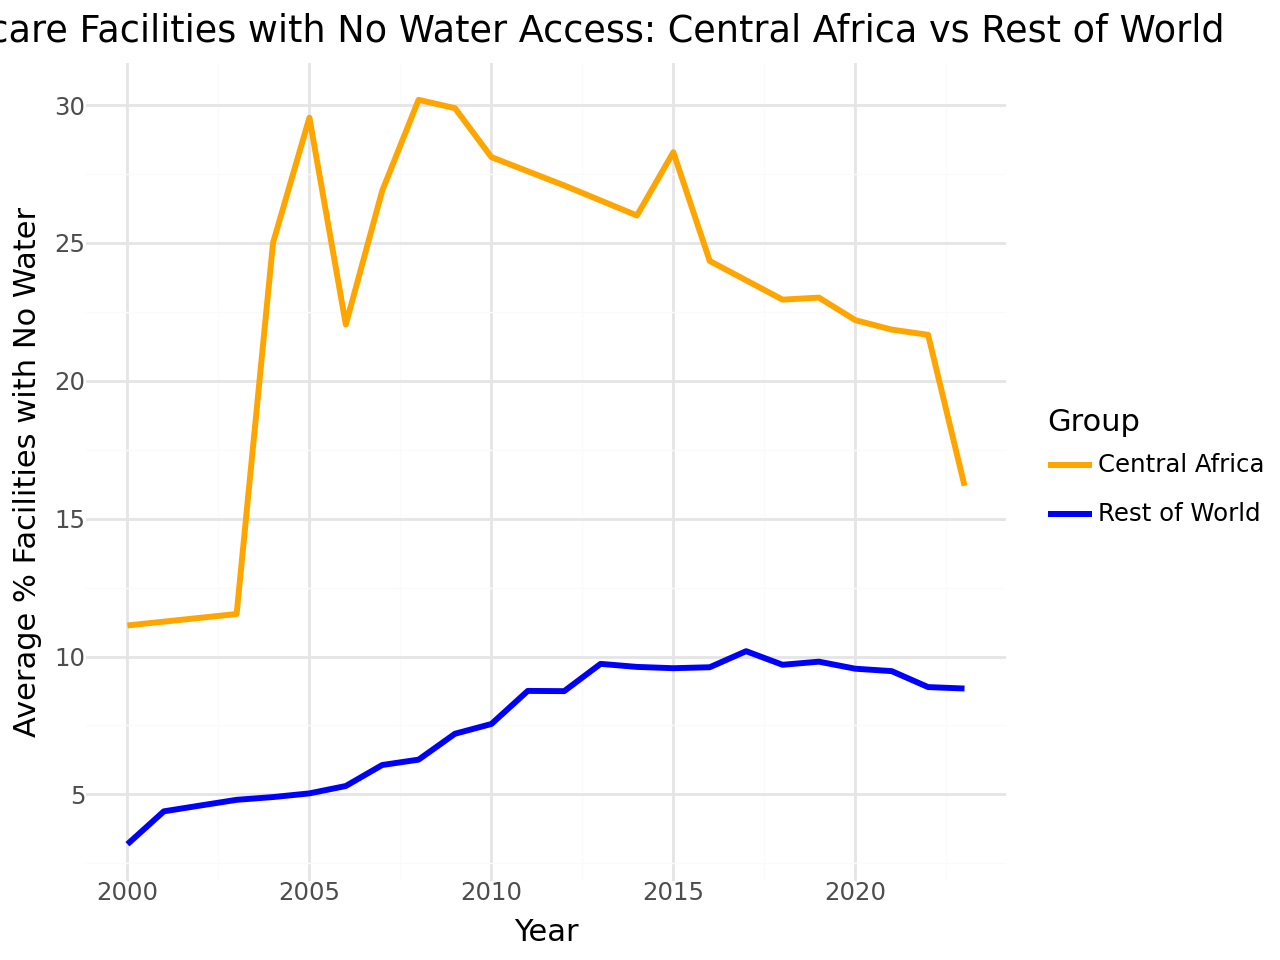

In [18]:
from plotnine import *

central_africa = ["Angola", "Burundi", "Cameroon", "Central African Republic", "Chad", "Congo", "Congo, the Democratic Republic of the", "Gabon", "Rwanda"]

indicator_grouped = indicator.with_columns(
    pl.when(pl.col("country").is_in(central_africa))
    .then(pl.lit("Central Africa"))
    .otherwise(pl.lit("Rest of World"))
    .alias("group")
)

avg_by_group = (
    indicator_grouped
    .group_by(["time_period", "group"])
    .agg(pl.col("obs_value").mean())
    .sort("time_period")
    .to_pandas()
)

(
    ggplot(avg_by_group)
    + aes(x="time_period", y="obs_value", color="group")
    + geom_line(size=1.2)
    + scale_y_continuous(breaks=range(0, 105, 5))
    + scale_color_manual(values={"Central Africa": "orange", "Rest of World": "blue"})
    + labs(
        title="Healthcare Facilities with No Water Access: Central Africa vs Rest of World",
        x="Year",
        y="Average % Facilities with No Water",
        color="Group"
    )
    + theme_minimal()
)

This showcases that the Central African region remains disadvantaged in terms of water access, whilst ***8.84%*** of health services ***globally*** had no water access, this figure stood at ***16.20% in Central Africa,*** during the same time period. This reached a high in 2008 with a figure of ***30.2%***, showcasing how this has improved in recent years. Althhough, this still remains concerning.

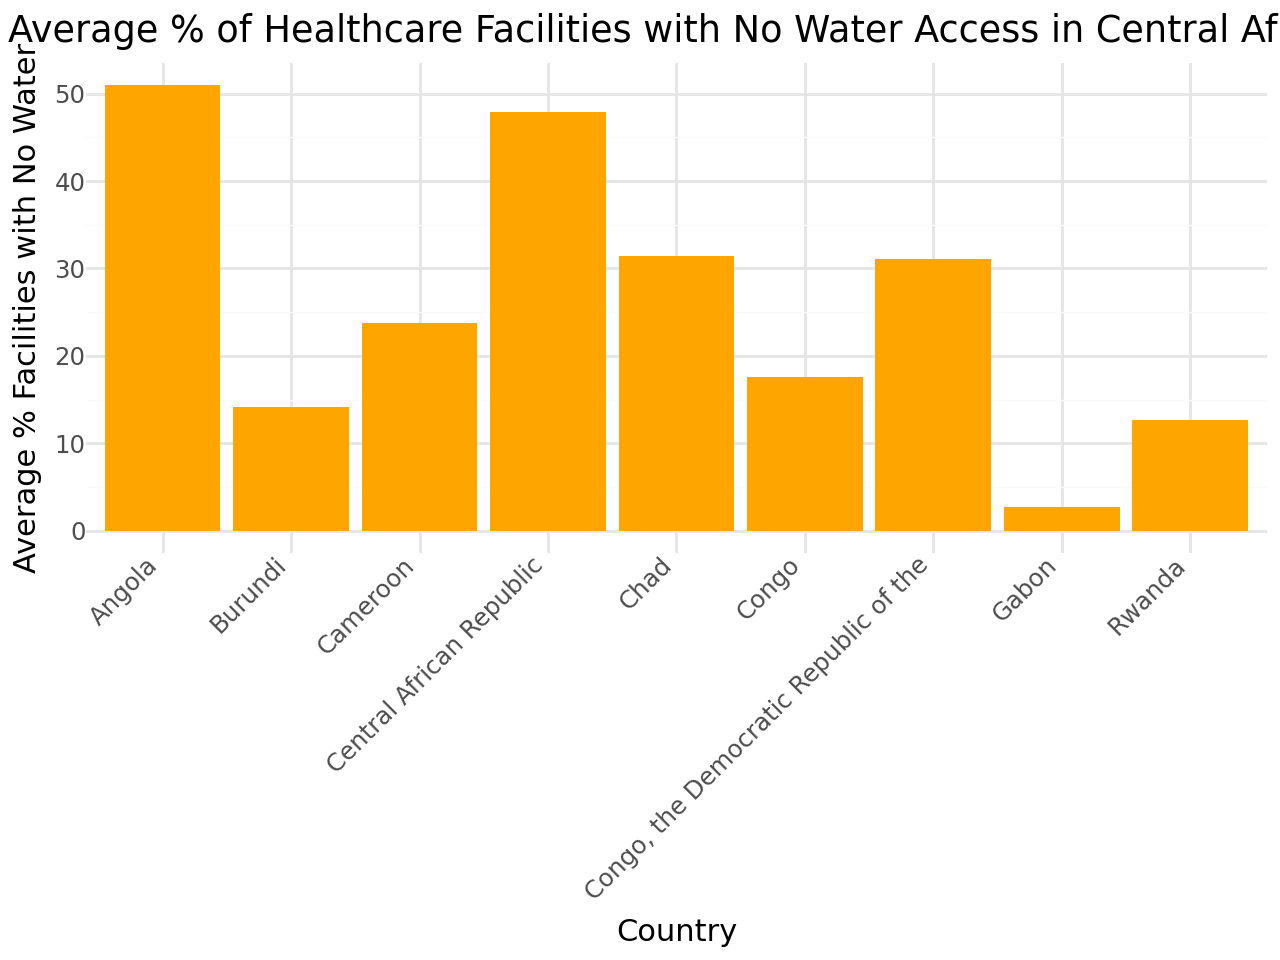

In [19]:
central_africa = ["Angola", "Burundi", "Cameroon", "Central African Republic", "Chad", "Congo", "Congo, the Democratic Republic of the", "Gabon", "Rwanda"]

indicator_ca = indicator.filter(pl.col("country").is_in(central_africa)).to_pandas()

avg_by_country = indicator_ca.groupby("country")["obs_value"].mean().reset_index()

(
    ggplot(avg_by_country)
    + aes(x="country", y="obs_value")
    + geom_bar(stat="identity", fill="orange")
    + labs(
        title="Average % of Healthcare Facilities with No Water Access in Central Africa",
        x="Country",
        y="Average % Facilities with No Water"
    )
    + theme_minimal()
    + theme(axis_text_x=element_text(angle=45, hjust=1))
)

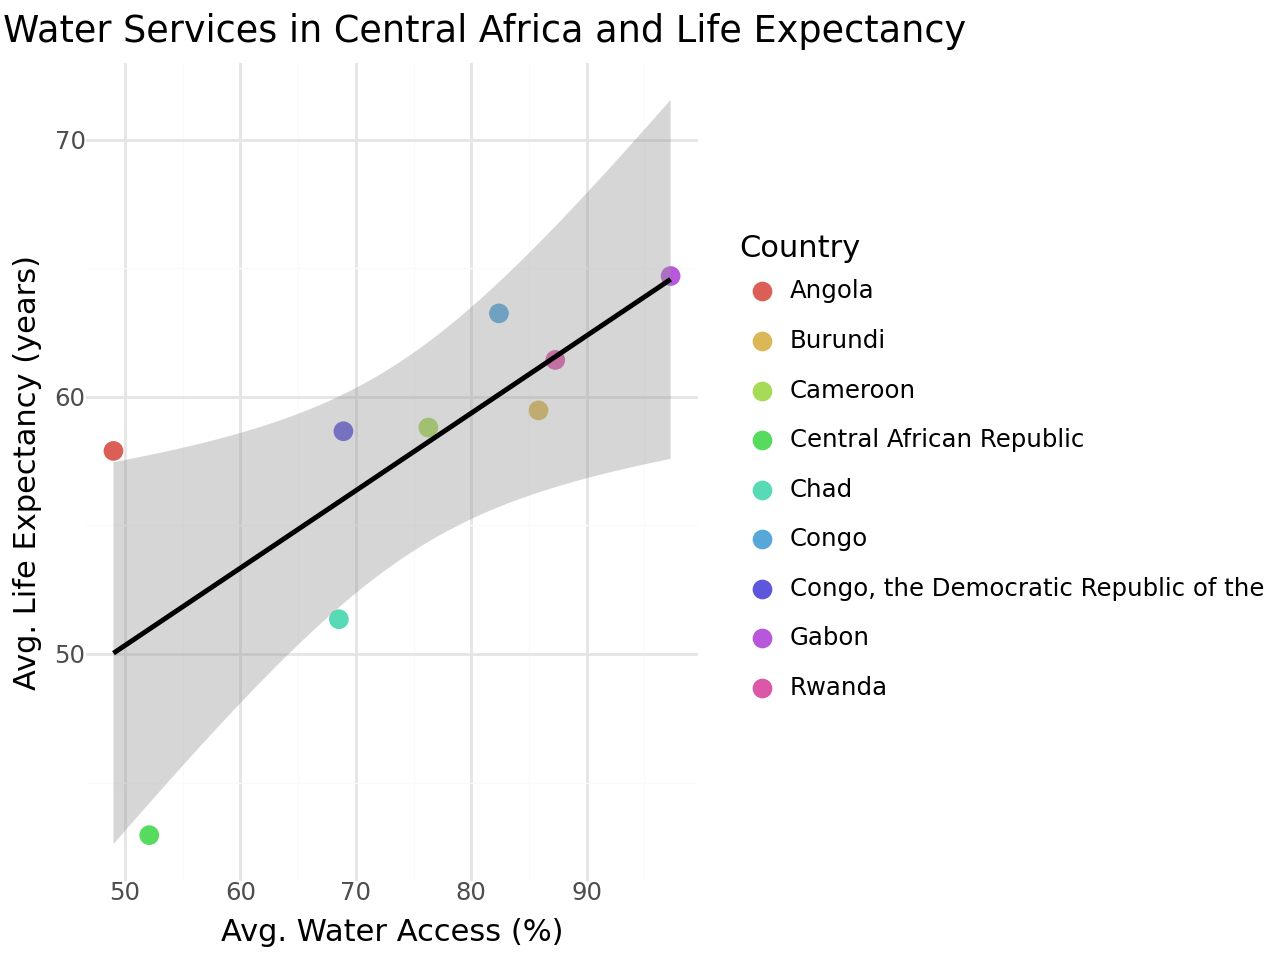

In [20]:
central_africa = ["Angola", "Burundi", "Cameroon", "Central African Republic", "Chad", "Congo", "Congo, the Democratic Republic of the", "Gabon", "Rwanda"]

indicator_ca = indicator.filter(pl.col("country").is_in(central_africa))

merged = indicator_ca.join(metadata, left_on=["country", "time_period"], right_on=["country", "year"], how="left")

merged_pd = merged.drop_nulls(subset=["obs_value", "Life expectancy at birth, total (years)"]).to_pandas()

merged_pd["water_access"] = 100 - merged_pd["obs_value"]

avg_merged = merged_pd.groupby("country")[["water_access", "Life expectancy at birth, total (years)"]].mean().reset_index()

(
    ggplot(avg_merged)
    + aes(x="water_access", y="Life expectancy at birth, total (years)", color="country")
    + geom_point(size=3)
    + geom_smooth(method="lm", color="black")
    + labs(
        title="Access to Water Services in Central Africa and Life Expectancy",
        x="Avg. Water Access (%)",
        y="Avg. Life Expectancy (years)",
        color="Country"
    )
    + theme_minimal()
)


In [21]:
from scipy import stats

correlation, p_value = stats.pearsonr(avg_merged["water_access"], avg_merged["Life expectancy at birth, total (years)"])

print(f"P-value: {p_value:.3f}")
print(f"R-squared: {correlation**2:.3f}")

P-value: 0.026
R-squared: 0.532


The *p-value* shows that **0.026>0.05**, implying that there is a significant relationship.

The *r-squared value* implies that **(0.532) 53.2%** of variance in water access is associated with average life expectancy.

Hence, this analysis provides a better insight into how water access seriously impacts people's lives and the consequences associated with this limited access, with countrues that have greater water access such as Gabon and Rwanda, having higher life expectancies.



Many people across the globe face **unsafe** and **unsanitary** conditions when receiving medical treatments.

UNICEF have attributed **many global deaths** due to this issue, which is exemplified by the graph showcasing life expectancy and water access.

They also highlight that this repeatedly affects the **world's least developed coutries and regions**.

Consequently, UNICEF have released a roadmap establishing a series of steps to overcome this challenge and **improve conditions for millios worlwide.**
